In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})


In [7]:
lchs_data = np.load("lchs_tfim_data.npz")
t_vals = lchs_data["t_vals"]
obs_gt = lchs_data["obs_gt"]
lchs_obs_sim = lchs_data["observable_sim_simuq"] 
lchs_std_error_sim = lchs_data["std_error_sim_simuq"]
lchs_observable_qpu = lchs_data["observable_qpu_simuq"]
lchs_std_error_qpu = lchs_data["std_error_qpu_simuq"]

schrodingerization_data = np.load("schrodingerization_tfim_data.npz")
schro_obs_sim = schrodingerization_data["obs_sim_simuq"]
schro_std_error_sim = schrodingerization_data["std_error_sim_simuq"]
schro_qpu = schrodingerization_data["obs_qpu_simuq"]
schro_std_error_qpu = schrodingerization_data["std_error_qpu_simuq"]

lchs_color = '#1f77b4'  # Hex code for blue
schr_color = '#d62728'  # Hex code for red

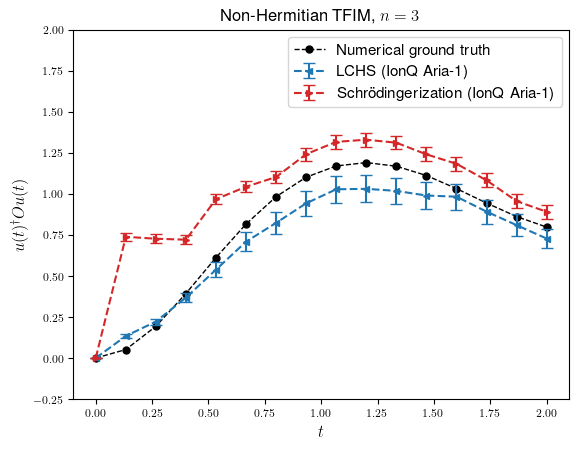

In [8]:
plt.figure()
plt.plot(t_vals, obs_gt, '--o', markersize=5, color="black", label="Numerical ground truth", linewidth=1)
plt.errorbar(t_vals, lchs_observable_qpu, lchs_std_error_qpu, fmt='--<', markersize=5, color=lchs_color, label="LCHS (IonQ Aria-1)", capsize=4)
plt.errorbar(t_vals, schro_qpu, schro_std_error_qpu, fmt='-->', markersize=5, color=schr_color, label="Schrödingerization (IonQ Aria-1)", capsize=4)
plt.ylabel(r"$u(t)^\dagger O u(t)$", fontsize=12)
plt.xlabel(r"$t$", fontsize=12)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.legend(fontsize=11)
plt.ylim(-0.25, 2)
plt.title(f"Non-Hermitian TFIM, $n=3$")
plt.savefig('../figures/tfim_fig.pdf', bbox_inches='tight')

Resource analysis

In [9]:
schrodingerization_data = np.load("../data/1d_tfim/schrodingerization.npz")
n_vals_schro = schrodingerization_data["n_vals"]
schrodingerization_trotter_steps = schrodingerization_data["schrodingerization_trotter_steps"]
schrodingerization_one_qubit_gate_count_per_trotter_step = schrodingerization_data["schrodingerization_one_qubit_gate_count_per_trotter_step"]
schrodingerization_two_qubit_gate_count_per_trotter_step = schrodingerization_data["schrodingerization_two_qubit_gate_count_per_trotter_step"]
schro_gate_count = schrodingerization_trotter_steps * (schrodingerization_one_qubit_gate_count_per_trotter_step + schrodingerization_two_qubit_gate_count_per_trotter_step)
schro_fit = np.polyfit(np.log(n_vals_schro), np.log(schro_gate_count), deg=1)


lchs_data = np.load("../data/1d_tfim/lchs.npz")
n_vals_lchs = lchs_data["n_vals"][:len(n_vals_schro)]
lchs_trotter_steps = lchs_data["lchs_trotter_steps"][:len(n_vals_schro)]
lchs_one_qubit_gate_count_per_trotter_step = lchs_data["lchs_one_qubit_gate_count_per_trotter_step"][:len(n_vals_schro)]
lchs_two_qubit_gate_count_per_trotter_step = lchs_data["lchs_two_qubit_gate_count_per_trotter_step"][:len(n_vals_schro)]
lchs_gate_count = lchs_trotter_steps * (lchs_one_qubit_gate_count_per_trotter_step + lchs_two_qubit_gate_count_per_trotter_step)
lchs_fit = np.polyfit(np.log(n_vals_lchs), np.log(lchs_gate_count), deg=1)



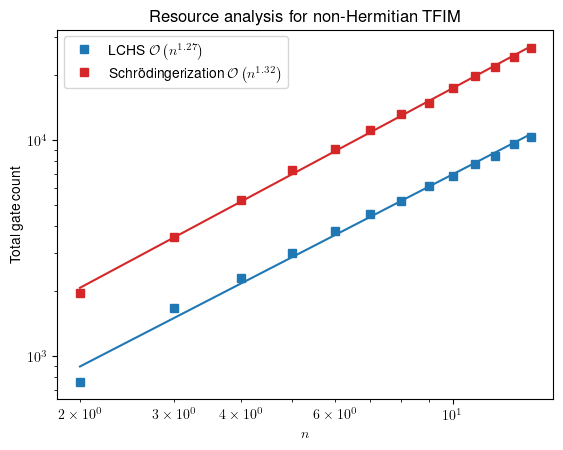

In [10]:
TICK_FONT = 5
LEGEND_FONT = 7
LABEL_FONT = 7
TITLE_FONT = 8

plt.plot(n_vals_lchs, lchs_gate_count, marker='s', linestyle="None", color=lchs_color, label=rf"LCHS $\mathcal{{O}}\left(n^{{{lchs_fit[0]:0.2f}}}\right)$")
plt.plot(n_vals_lchs, (n_vals_lchs ** lchs_fit[0]) * np.exp(lchs_fit[1]), color=lchs_color)
plt.plot(n_vals_schro, schro_gate_count, marker='s', linestyle="None", color=schr_color, label=rf"Schrödingerization $\mathcal{{O}}\left(n^{{{schro_fit[0]:0.2f}}}\right)$")
plt.plot(n_vals_schro, (n_vals_schro ** schro_fit[0]) * np.exp(schro_fit[1]), color=schr_color)
plt.ylabel("Total gate count")
plt.xlabel(r"$n$")
plt.title("Resource analysis for non-Hermitian TFIM")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.savefig("../figures/tfim_resource_analysis.pdf", bbox_inches="tight")
plt.show()